In [42]:
import os
import numpy as np
import pandas as pd
import mne
from mne.preprocessing import ICA, corrmap, create_ecg_epochs, create_eog_epochs
import matplotlib.pyplot as plt
#%matplotlib inline
from scipy.fft import fft
from eeg_loader import read_file, load_eeg, get_eeg_timestamps, load_event, detect_signal_start
import yaml
from datetime import timedelta
import PyQt5


## Preprocess Data

### Step 1: Filter and make trials


In [43]:
# Load eeg data
eeg_file_path = "CON004_clipped.EDF"  

raw = mne.io.read_raw(eeg_file_path, preload=True)

Extracting EDF parameters from /Users/trishaprasant/Documents/DATA590/CON004_clipped.EDF...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 2495999  =      0.000 ...  4874.998 secs...


/var/folders/kp/42tvxzv924xdtdyzydmjjp380000gn/T/ipykernel_38294/2569318835.py:4: RuntimeWarning: Omitted 5 annotation(s) that were outside data range.
  raw = mne.io.read_raw(eeg_file_path, preload=True)


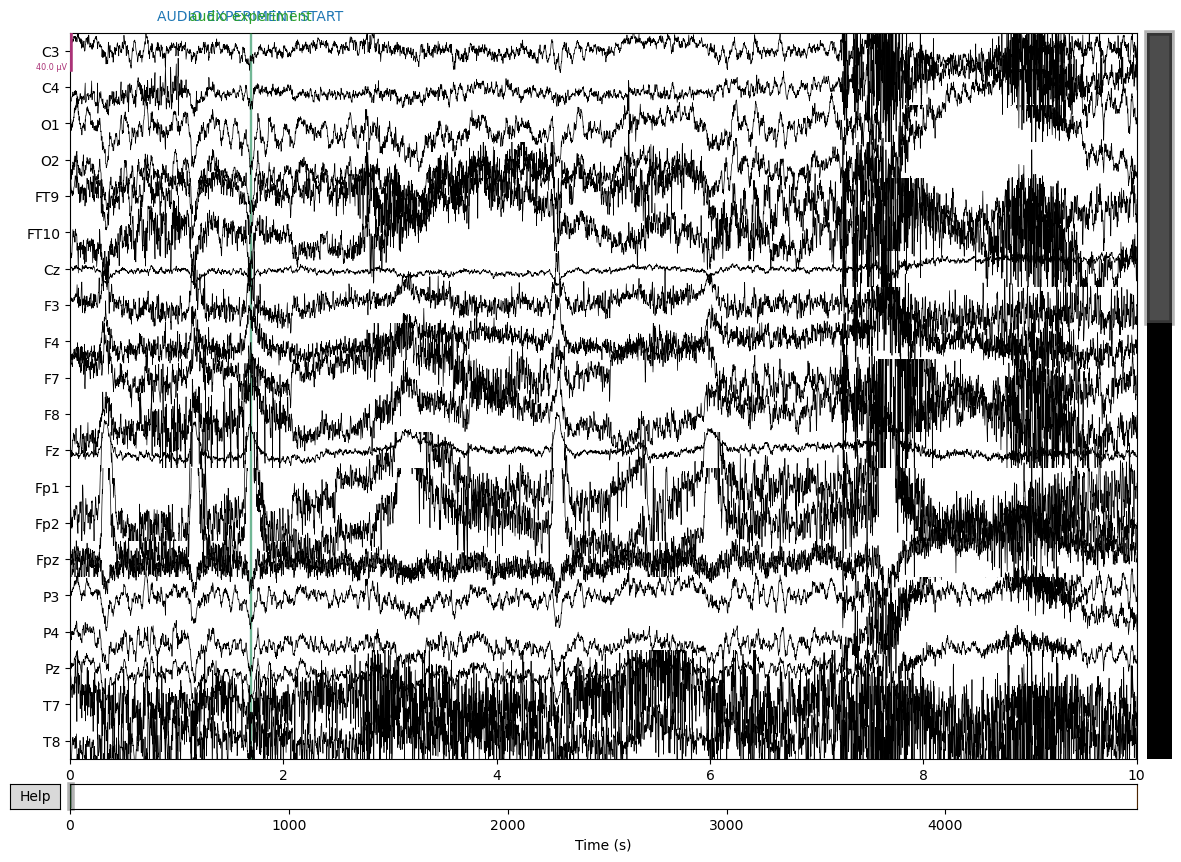

In [44]:
%matplotlib qt
raw.plot()


In [45]:
non_eeg_channels = ['IO1', 'IO2', 'EMG1', 'EMG2', 'ECGL', 'ECGR', 'LAT1', 'LAT2', 'RAT1', 'RAT2', 'RESP', 'ABD', 'FLOW', 'SNORE', 'DIF5','DIF6', 'POS', 'DC2', 'DC3', 'DC4', 'DC5', 'DC6', 'DC7','DC8','DC9','DC10', 'OSAT', 'PR']
raw.drop_channels(non_eeg_channels)

use_ch = ['C3','C4','O1','O2','FT9','FT10','Cz','F3','F4','F7','F8','Fz','Fp1','Fp2','Fpz','P3','P4','Pz','T7','T8','P7','P8']
raw.pick_channels(use_ch)
raw.info["bads"].extend(['Fp1', 'Fp2', 'T7']) 

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


In [46]:
#Notch filter at 48 to 52 hz and 98 to 102 hz and 148 to 152 hz
raw.notch_filter(freqs=[48, 50, 52], filter_length='auto', picks='eeg')
raw.notch_filter(freqs=[98, 100, 102], filter_length='auto', picks='eeg')
raw.notch_filter(freqs=[148, 150, 152], filter_length='auto', picks='eeg')

#Band pass filter between 0.01 and 100 hz
raw.filter(l_freq=0.01, h_freq=100)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 3381 samples (6.604 s)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.1s remaining:    0.0s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 3381 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  22 out of  22 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.1s remaining:    0.0s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 3381 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  22 out of  22 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.1s remaining:    0.0s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.01 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.01
- Lower transition bandwidth: 0.01 Hz (-6 dB cutoff frequency: 0.01 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 168961 samples (330.002 s)



[Parallel(n_jobs=1)]: Done  22 out of  22 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  22 out of  22 | elapsed:    1.2s finished


<RawEDF | CON004_clipped.EDF, 22 x 2496000 (4875.0 s), ~419.0 MiB, data loaded>

### Step 2: Create Events from CSV

In [47]:
import pandas as pd

# Load CSV with stimulus onset times
stimulus_df = pd.read_csv("patient_df.csv")

# Clean the data
stimulus_df = stimulus_df.drop(columns=['Unnamed: 0'])
stimulus_df = stimulus_df[stimulus_df['patient_id'].isin(["CON004"])]
stimulus_df = stimulus_df[stimulus_df['trial_type'] == 'lang']
    
# Convert Unix timestamps to datetime
stimulus_df["start_time"] = pd.to_datetime(stimulus_df["start_time"], unit="s")
stimulus_df["end_time"] = pd.to_datetime(stimulus_df["end_time"], unit="s")

# Subtract 7 hours from start and end times to match EEG data
stimulus_df["start_time"] = stimulus_df["start_time"] - pd.Timedelta(hours=8)
stimulus_df["end_time"] = stimulus_df["end_time"] - pd.Timedelta(hours=8)

# Print to verify format
stimulus_df.head()

,patient_id,date,trial_type,sentences,start_time,end_time,duration
504,CON004,2025-01-30,lang,"[5, 16, 24, 27, 23, 10, 29, 1, 14, 3, 0, 2]",2025-01-30 15:56:20.198473728,2025-01-30 15:56:35.789033472,15.590560
505,CON004,2025-01-30,lang,"[21, 0, 13, 26, 16, 31, 1, 33, 2, 23, 32, 24]",2025-01-30 15:56:37.324819456,2025-01-30 15:56:52.886157568,15.561338
507,CON004,2025-01-30,lang,"[0, 12, 7, 20, 23, 4, 32, 29, 11, 3, 24, 16]",2025-01-30 16:00:24.231351552,2025-01-30 16:00:39.799087104,15.567735
508,CON004,2025-01-30,lang,"[30, 26, 24, 3, 12, 15, 22, 23, 21, 5, 9, 11]",2025-01-30 16:00:41.917766144,2025-01-30 16:00:57.484492288,15.566726
510,CON004,2025-01-30,lang,"[22, 3, 20, 31, 27, 8, 4, 19, 26, 13, 12, 23]",2025-01-30 16:01:31.323784960,2025-01-30 16:01:46.891122176,15.567337


In [48]:
eeg_start_time = raw.info["meas_date"]
eeg_start_time = pd.Timestamp(eeg_start_time)
eeg_start_time  = eeg_start_time.replace(tzinfo=None)

In [49]:
eeg_start_time

Timestamp('2025-01-30 15:45:40')

In [50]:
# Compute relative times to find distance from eeg start times 
stimulus_df["relative_start_time"] = (stimulus_df["start_time"] - eeg_start_time).dt.total_seconds()
stimulus_df["relative_end_time"] = (stimulus_df["end_time"] - eeg_start_time).dt.total_seconds()

sfreq = raw.info["sfreq"]

# Calculate Sample indices to match with EEG recording
stimulus_df["start_sample"] = (stimulus_df["relative_start_time"] * sfreq).astype(int)
stimulus_df["end_sample"] = (stimulus_df["relative_end_time"] * sfreq).astype(int)

In [51]:
stimulus_df

,patient_id,date,trial_type,sentences,start_time,end_time,duration,relative_start_time,relative_end_time,start_sample,end_sample
504,CON004,2025-01-30,lang,"[5, 16, 24, 27, 23, 10, 29, 1, 14, 3, 0, 2]",2025-01-30 15:56:20.198473728,2025-01-30 15:56:35.789033472,15.590560,640.198474,655.789033,327781,335763
505,CON004,2025-01-30,lang,"[21, 0, 13, 26, 16, 31, 1, 33, 2, 23, 32, 24]",2025-01-30 15:56:37.324819456,2025-01-30 15:56:52.886157568,15.561338,657.324819,672.886158,336550,344517
507,CON004,2025-01-30,lang,"[0, 12, 7, 20, 23, 4, 32, 29, 11, 3, 24, 16]",2025-01-30 16:00:24.231351552,2025-01-30 16:00:39.799087104,15.567735,884.231352,899.799087,452726,460697
508,CON004,2025-01-30,lang,"[30, 26, 24, 3, 12, 15, 22, 23, 21, 5, 9, 11]",2025-01-30 16:00:41.917766144,2025-01-30 16:00:57.484492288,15.566726,901.917766,917.484492,461781,469752
510,CON004,2025-01-30,lang,"[22, 3, 20, 31, 27, 8, 4, 19, 26, 13, 12, 23]",2025-01-30 16:01:31.323784960,2025-01-30 16:01:46.891122176,15.567337,951.323785,966.891122,487077,495048
...,...,...,...,...,...,...,...,...,...,...,...
583,CON004,2025-01-30,lang,"[15, 22, 9, 2, 5, 18, 24, 31, 17, 32, 11, 1]",2025-01-30 16:39:46.123362304,2025-01-30 16:40:01.696470528,15.573108,3246.123362,3261.696471,1662015,1669988
584,CON004,2025-01-30,lang,"[5, 15, 21, 27, 3, 0, 6, 11, 10, 32, 19, 18]",2025-01-30 16:40:03.458804992,2025-01-30 16:40:19.017624832,15.558820,3263.458805,3279.017625,1670890,1678857
585,CON004,2025-01-30,lang,"[20, 19, 25, 30, 13, 23, 27, 16, 26, 14, 22, 2]",2025-01-30 16:40:20.634123776,2025-01-30 16:40:36.202791680,15.568668,3280.634124,3296.202792,1679684,1687655
586,CON004,2025-01-30,lang,"[8, 32, 0, 11, 25, 18, 24, 7, 10, 23, 3, 17]",2025-01-30 16:40:37.641665024,2025-01-30 16:40:53.204037888,15.562373,3297.641665,3313.204038,1688392,1696360


In [52]:
"""
# Plot the DC7 signal with detected lang onsets marked
plt.figure(figsize=(10, 6))
plt.plot(time_stamps, stimulus_data, label='DC7 (Stimulus Marker)')

for start_time in relative_start_times_new:
    plt.axvline(x=start_time, color='r', linestyle='-')
    
for start_time in relative_end_times_new:
    plt.axvline(x=start_time, color='b', linestyle='-')

plt.title('Detected Lang Onsets in DC7 Channel')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')
plt.legend()
plt.grid(True)
plt.show()

# Print the detected lang onset times
"""

"\n# Plot the DC7 signal with detected lang onsets marked\nplt.figure(figsize=(10, 6))\nplt.plot(time_stamps, stimulus_data, label='DC7 (Stimulus Marker)')\n\nfor start_time in relative_start_times_new:\n    plt.axvline(x=start_time, color='r', linestyle='-')\n    \nfor start_time in relative_end_times_new:\n    plt.axvline(x=start_time, color='b', linestyle='-')\n\nplt.title('Detected Lang Onsets in DC7 Channel')\nplt.xlabel('Time (s)')\nplt.ylabel('Amplitude (V)')\nplt.legend()\nplt.grid(True)\nplt.show()\n\n# Print the detected lang onset times\n"

In [53]:
#check correct
print("Min Event Sample:", stimulus_df["start_sample"].min())
print("Max Event Sample:", stimulus_df["start_sample"].max())
print("EEG Recording Sample Range: 0 to", raw.n_times - 1)

Min Event Sample: 327781
Max Event Sample: 1697365
EEG Recording Sample Range: 0 to 2495999


In [54]:
start_samples = np.array(stimulus_df["start_sample"])

In [55]:
# Create Annotations for each "lang" trial
annotations = []
for start_sample in start_samples:
    annotations.append(mne.Annotations(onset=start_sample / raw.info['sfreq'],  # onset in seconds
                                       duration=stimulus_df['duration'].iloc[0],  # duration in seconds
                                       description='lang'))  # Custom description for "lang" events

In [56]:
# Add annotations to the Raw object
raw.set_annotations(mne.Annotations(
    onset=np.ravel([a.onset for a in annotations]),  # Flatten the onset array
    duration=np.ravel([a.duration for a in annotations]),
    description=np.ravel([a.description for a in annotations])
))

<RawEDF | CON004_clipped.EDF, 22 x 2496000 (4875.0 s), ~419.0 MiB, data loaded>

In [57]:
# Create events based on the annotations
events, event_id = mne.events_from_annotations(raw)

Used Annotations descriptions: ['lang']


In [58]:
"""
%matplotlib qt
raw.plot(
    events=events,
    start=5,
    duration=10,
    color="gray",
    event_color={1: "r", 2: "g"},
)
"""

'\n%matplotlib qt\nraw.plot(\n    events=events,\n    start=5,\n    duration=10,\n    color="gray",\n    event_color={1: "r", 2: "g"},\n)\n'

### Step 2b: Create epochs

In [59]:
"""
length of 4 word sentence = 0.32 * 4 
number of sentences played per trial = 12

start the epoch 1 second ebfore stimulus
end epoch at the end of stimulus after all 12 sentences (each 1.28 seconds) have been played
"""

# Create epochs each with length of 16.36 seconds 

start_time = -1  # Start 1 second before the stimulus
end_time = 12 * 1.28  # 12 sentences * 1.28s each = 15.36

# Define epochs: from -1s before to 3.84s after the stimulus
epochs = mne.Epochs(raw, events, event_id=None, tmin=start_time, tmax=end_time, baseline=None, preload=True)

Not setting metadata
72 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 72 events and 8377 original time points ...
0 bad epochs dropped


In [60]:
# Downsample to 256 hz
epochs.info['bads'] = raw.info['bads']
epochs.resample(256)
raw.resample(256)

<RawEDF | CON004_clipped.EDF, 22 x 1248000 (4875.0 s), ~209.5 MiB, data loaded>

### Step 3: Visual Inspection of Data

In [61]:
#View epochs
#%matplotlib inline
#epochs.plot();

### Step 4: ICA for blinks and horizontal eye movements

In [62]:
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)

<RawEDF | CON004_clipped.EDF, 22 x 1248000 (4875.0 s), ~209.5 MiB, data loaded>

In [63]:
reject = dict(mag=5e-12, grad=4000e-13)

ica = ICA(n_components=15, max_iter="auto", random_state=97)
ica.fit(raw) # add :, reject=reject
ica

Fitting ICA to data using 19 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 6.2s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,39 iterations on raw data (1248000 samples)
ICA components,15
Available PCA components,19
Channel types,eeg
ICA components marked for exclusion,—


In [64]:
ica.plot_sources(raw);

Creating RawArray with float64 data, n_channels=15, n_times=1248000
    Range : 0 ... 1247999 =      0.000 ...  4874.996 secs
Ready.


In [65]:
ica.plot_components(); 

In [66]:
explained_var_ratio = ica.get_explained_variance_ratio(raw)
for channel_type, ratio in explained_var_ratio.items():
    print(f"Fraction of {channel_type} variance explained by all components: {ratio}")

Fraction of eeg variance explained by all components: 0.9971787778298596


In [67]:
eog_components, eog_scores = ica.find_bads_eog(
    inst=raw,
    ch_name="Fpz",  # a channel close to the eye
    threshold=1,  # lower than the default threshold
)

Using EOG channel: Fpz
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2560 samples (10.000 s)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.1s remaining:    0.0s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2560 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


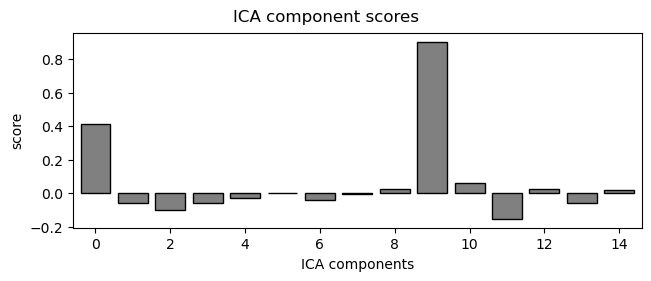

In [68]:
ica.plot_scores(eog_scores)

In [69]:
ica.exclude = eog_components

In [70]:
ica.plot_properties(raw, picks=[0, 9])


    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
2437 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
2437 matching events found
No baseline correction applied
0 projection items activated


[<Figure size 700x600 with 6 Axes>, <Figure size 700x600 with 6 Axes>]

In [71]:
ica.exclude = [0, 9]  # indices chosen based on various plots above

In [72]:
# Apply ICA rejection on epoched data
epochs_clean = ica.apply(epochs)  # Apply the rejection to the epoched data

Applying ICA to Epochs instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 19 PCA components


### Step 6:  Interpolate bad channels and rereference data to average

In [73]:
# interpolate noisy channels
epochs_clean.set_montage(montage)
epochs_clean.interpolate_bads()

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 96.0 mm
Computing interpolation matrix from 19 sensor positions
Interpolating 3 sensors


<Epochs | 72 events (all good), -1 – 15.355 s (baseline off), ~50.6 MiB, data loaded,
 '1': 72>

In [74]:
# Re-reference to average
epochs_clean.set_eeg_reference('average', projection=True)
epochs_clean.apply_proj()

EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


<Epochs | 72 events (all good), -1 – 15.355 s (baseline off), ~50.6 MiB, data loaded,
 '1': 72>

### Step 7: ITPC Calculation

In [75]:
# Filter data below 25 hz
epochs_clean.filter(l_freq=0.1, h_freq=25, method='iir')

Setting up band-pass filter from 0.1 - 25 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.10, 25.00 Hz: -6.02, -6.02 dB



<Epochs | 72 events (all good), -1 – 15.355 s (baseline off), ~50.6 MiB, data loaded,
 '1': 72>

In [76]:
# Remove first 4 word sentence to avoid transient EEG response (add 1 second to 1.28 since we started at -1 before audio stream)
epochs_clean.crop(tmin=1.28)

<Epochs | 72 events (all good), 1.281 – 15.355 s (baseline off), ~43.6 MiB, data loaded,
 '1': 72>

## ITPC Calculation

In [77]:
epochs_data = epochs_clean.get_data()
n_trials, n_electrodes, n_samples = epochs_data.shape
epochs_data.shape

(72, 22, 3604)

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fftpack

def compute_itpc(epochs_data, fs=256):
    """
    Compute Inter-Trial Phase Coherence from epoched data
    
    Parameters:
    -----------
    epochs_data : ndarray
        Shape (n_trials, n_electrodes, n_samples)
    fs : float
        Sampling frequency in Hz
        
    Returns:
    --------
    itpc : ndarray
        Shape (n_frequencies, n_electrodes)
    freqs : ndarray
        Frequency values
    phase_data : ndarray
        Complex phase data with shape (n_frequencies, n_electrodes, n_trials)
    """
    # Transpose to match MATLAB's format (time x channel x trial)
    data = np.transpose(epochs_data, (2, 1, 0))  # (n_samples, n_electrodes, n_trials)
    
    n_samples, n_electrodes, n_trials = data.shape
    
    # Define all frequencies (equivalent to MATLAB's f calculation)
    freqs = np.fft.fftfreq(n_samples, 1/fs)
    
    # Initialize arrays
    itpc = np.zeros((n_samples, n_electrodes))
    phase_data = np.zeros((n_samples, n_electrodes, n_trials), dtype=complex)
    
    # ITPC loop -> 1 ITPC value per electrode and frequency
    for el in range(n_electrodes):
        # Initialize array for complex exponentials
        exp_k = np.zeros((n_samples, n_trials), dtype=complex)
        
        for tr in range(n_trials):
            # Get data for current channel and trial
            x_chan_trl = data[:, el, tr]
            
            # Compute DFT
            y = fftpack.fft(x_chan_trl)
            
            # Get phase angles
            p = np.angle(y)
            
            # Compute complex exponential of phase (e^(i*p))
            exp_k[:, tr] = np.exp(1j * p)
            phase_data[:, el, tr] = np.exp(1j * p)
        
        print(f"Computing channel #{el+1}")
        
        # Compute ITPC by taking absolute value of mean across trials
        itpc[:, el] = np.abs(np.mean(exp_k, axis=1))
    
    return itpc, freqs, phase_data

# Apply the function to your data
itpc, freqs, phase_data = compute_itpc(epochs_data, fs=256)  # Adjust fs to your actual sampling rate

Computing channel #1
Computing channel #2
Computing channel #3
Computing channel #4
Computing channel #5
Computing channel #6
Computing channel #7
Computing channel #8
Computing channel #9
Computing channel #10
Computing channel #11
Computing channel #12
Computing channel #13
Computing channel #14
Computing channel #15
Computing channel #16
Computing channel #17
Computing channel #18
Computing channel #19
Computing channel #20
Computing channel #21
Computing channel #22


In [79]:
itpc.shape

(3604, 22)

In [80]:
import matplotlib.pyplot as plt
import numpy as np

def plot_itpc_each_channel(itpc, freqs, fmin=0.5, fmax=4):
    """
    Plot ITPC values for each channel in separate figures.
    
    Parameters:
    -----------
    itpc : ndarray
        ITPC array of shape (n_frequencies, n_channels)
    freqs : ndarray
        Frequency values (can include both negative and positive frequencies)
    fmin : float
        Minimum frequency to display on the x-axis
    fmax : float
        Maximum frequency to display on the x-axis
    """
    # Select only positive frequencies up to fmax
    pos_idx = (freqs >= 0) & (freqs <= fmax)
    plot_freqs = freqs[pos_idx]
    n_channels = itpc.shape[1]
    
    for ch in range(n_channels):
        channel_itpc = itpc[pos_idx, ch]
        plt.figure(figsize=(8, 5))
        plt.plot(plot_freqs, channel_itpc, color='b')
        plt.title(f'ITPC for {ch_names[ch]}')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('ITPC')
        plt.xlim(fmin, fmax)
        plt.grid(True)
        plt.show()  # This will open a new window for each channel

# Example usage:
ch_names = epochs.info['ch_names']  # Replace with your channel names source
plot_itpc_each_channel(itpc, freqs, fmin=0.5, fmax=4)

/var/folders/kp/42tvxzv924xdtdyzydmjjp380000gn/T/ipykernel_38294/387033523.py:26: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 5))


In [81]:
# To visualize ITPC across frequencies for all electrodes (averaged)
def plot_itpc(itpc, freqs, fmin=0.5, fmax=4):
    # Get positive frequencies and corresponding ITPC values
    pos_idx = (freqs >= 0) & (freqs <= fmax)
    plot_freqs = freqs[pos_idx]
    plot_itpc = itpc[pos_idx, :]
    
    # Average ITPC across electrodes
    avg_itpc = np.mean(plot_itpc, axis=1)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(plot_freqs, avg_itpc)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('ITPC')
    plt.title('ITPC Averaged over all Channels')
    plt.xlim(fmin, fmax)
    plt.ylim(0.01, 0.5)
    plt.grid(True)
    plt.show()
    
    return avg_itpc, plot_freqs

# Plot the results
avg_itpc, plot_freqs = plot_itpc(itpc, freqs)